# GEBCO 2025 — raw vs STAC folder vs cloud

Checks that the four GEBCO tiles are the same in the three places they live:

1. **Raw**: `P:\...\Data_Vivian\gebco_2025_sub_ice_*.tif` (original GeoTIFFs)
2. **STAC folder**: `P:\...\Data_Vivian\stac\gebco\cog\*.tif` (COGs produced by `notebooks/21_gebco.ipynb`)
3. **Cloud**: the COGs found through the public STAC catalog (`gca-stac-7`, collection `gebco`)

The tiles are huge (21600 x 21600 pixels each), so they are **not read completely**:
- the plots use a decimated read (every `DECIMATE`-th pixel; COGs are read from their overviews),
- the pixel comparison uses `N_WINDOWS` random windows of `WINDOW` x `WINDOW` pixels per tile, identical for the three sources. Set `FULL_COMPARE = True` to compare every pixel of raw vs STAC folder (reads 3.7 GB twice, slow).

Environment: `environment_exploration.yml` (Miniforge).

In [8]:
import re
import time
from pathlib import Path
from posixpath import join as urljoin

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import rasterio
from matplotlib.colors import TwoSlopeNorm
from rasterio.windows import Window

## 1) Locations and options

In [9]:
data_vivian = Path(r"P:\11209117-041-ipdc-egypt-swi\data\IntDeltaPlatform_QGA\Data_Vivian")
stac_folder_dir = data_vivian / "stac" / "gebco" / "cog"

gcs_protocol = "https://storage.googleapis.com"
catalog_url = urljoin(gcs_protocol, "gca-data-public", "gca", "gca-stac-7", "catalog.json")
collection_id = "gebco"

DECIMATE = 20          # plot resolution: 21600 / 20 = 1080 pixels per tile
N_WINDOWS, WINDOW = 6, 1024
FULL_COMPARE = False
rng = np.random.default_rng(0)

def item_id_from(path: Path) -> str:
    return re.sub(r"(\d)\.0(?=_|$)", r"\1", path.stem)  # n0.0_s-90.0 -> n0_s-90 (same as the preprocessing)

raw_paths = {item_id_from(p): p for p in sorted(data_vivian.glob("gebco_2025_sub_ice_*.tif"))}
stac_folder_paths = {i: stac_folder_dir / f"{i}.tif" for i in raw_paths}
for i in raw_paths:
    print(i, raw_paths[i].is_file(), stac_folder_paths[i].is_file())

gebco_2025_sub_ice_n0_s-90_w-90_e0 True True
gebco_2025_sub_ice_n0_s-90_w0_e90 True True
gebco_2025_sub_ice_n90_s0_w-90_e0 True True
gebco_2025_sub_ice_n90_s0_w0_e90 True True


## 2) Find the data through the STAC catalog

In [10]:
# public objects are cached for 1 h: a query string forces a fresh copy of catalog.json
catalog = pystac_client.Client.open(f"{catalog_url}?nocache={time.time()}")
# get_collection() can return another collection on a static catalog: match the id explicitly
collection = next((c for c in catalog.get_children() if c.id == collection_id), None)
if collection is None:
    raise LookupError(f"Collection {collection_id} not found in {catalog_url}")

items = {i.id: i for i in collection.get_items()}
print("Collection:", collection.id, "|", collection.title)
print("Items:", list(items))
assert set(items) == set(raw_paths), "Catalog items and local tiles differ"

cloud_hrefs = {i: items[i].assets["data"].href for i in raw_paths}
for i, href in cloud_hrefs.items():
    assert collection_id in href, f"Unexpected href: {href}"
    print(f"{i}: bbox {items[i].bbox} | {href}")

c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\client.py:191: NoConformsTo: Server does not advertise any conformance classes.
  warnings.warn(NoConformsTo())


Collection: gebco | General Bathymetric Chart of the Oceans (GEBCO 2025 Grid)
Items: ['gebco_2025_sub_ice_n0_s-90_w-90_e0', 'gebco_2025_sub_ice_n0_s-90_w0_e90', 'gebco_2025_sub_ice_n90_s0_w-90_e0', 'gebco_2025_sub_ice_n90_s0_w0_e90']
gebco_2025_sub_ice_n0_s-90_w-90_e0: bbox [-90.0, -90.0, 0.0, 0.0] | https://storage.googleapis.com/gca-data-public/gca/gebco/gebco_2025_sub_ice_n0_s-90_w-90_e0.tif
gebco_2025_sub_ice_n0_s-90_w0_e90: bbox [-0.0, -90.0, 90.0, 0.0] | https://storage.googleapis.com/gca-data-public/gca/gebco/gebco_2025_sub_ice_n0_s-90_w0_e90.tif
gebco_2025_sub_ice_n90_s0_w-90_e0: bbox [-90.0, 0.0, 0.0, 90.0] | https://storage.googleapis.com/gca-data-public/gca/gebco/gebco_2025_sub_ice_n90_s0_w-90_e0.tif
gebco_2025_sub_ice_n90_s0_w0_e90: bbox [-0.0, 0.0, 90.0, 90.0] | https://storage.googleapis.com/gca-data-public/gca/gebco/gebco_2025_sub_ice_n90_s0_w0_e90.tif


c:\Users\fuentesm\AppData\Local\miniforge3\envs\gca-exploration\Lib\site-packages\pystac_client\collection_client.py:149: FallbackToPystac: Falling back to pystac. This might be slow.
  root._warn_about_fallback("ITEM_SEARCH")


## 3) Profiles and decimated read of every tile

In [11]:
labels = ["raw (P:)", "stac folder (P:)", "cloud (catalog)"]
paths = {i: dict(zip(labels, (str(raw_paths[i]), str(stac_folder_paths[i]), cloud_hrefs[i]))) for i in raw_paths}

profiles, previews = {}, {}
for i, srcs in paths.items():
    for label, path in srcs.items():
        with rasterio.open(path) as src:
            out_shape = (src.height // DECIMATE, src.width // DECIMATE)
            previews[(i, label)] = src.read(1, out_shape=out_shape, resampling=rasterio.enums.Resampling.nearest)
            profiles[(i, label)] = {
                "shape": src.shape,
                "dtype": src.dtypes[0],
                "nodata": src.nodata,
                "crs": src.crs.to_string() if src.crs else None,
                "transform": tuple(round(v, 6) for v in src.transform)[:6],
                "tiled (COG)": src.is_tiled,
                "overviews": src.overviews(1),
                "compression": str(src.compression),
                "bounds": tuple(round(v, 3) for v in src.bounds),
            }

pd.DataFrame(profiles).T

shape  dtype  \
gebco_2025_sub_ice_n0_s-90_w-90_e0 raw (P:)          (21600, 21600)  int16   
                                   stac folder (P:)  (21600, 21600)  int16   
                                   cloud (catalog)   (21600, 21600)  int16   
gebco_2025_sub_ice_n0_s-90_w0_e90  raw (P:)          (21600, 21600)  int16   
                                   stac folder (P:)  (21600, 21600)  int16   
                                   cloud (catalog)   (21600, 21600)  int16   
gebco_2025_sub_ice_n90_s0_w-90_e0  raw (P:)          (21600, 21600)  int16   
                                   stac folder (P:)  (21600, 21600)  int16   
                                   cloud (catalog)   (21600, 21600)  int16   
gebco_2025_sub_ice_n90_s0_w0_e90   raw (P:)          (21600, 21600)  int16   
                                   stac folder (P:)  (21600, 21600)  int16   
                                   cloud (catalog)   (21600, 21600)  int16   

                                                      nodata        crs  \
gebco_2025_sub_ice_n0_s-90_w-90_e0 raw (P:)         -32767.0  EPSG:4326   
                                   stac folder (P:) -32767.0  EPSG:4326   
                                   cloud (catalog)  -32767.0  EPSG:4326   
gebco_2025_sub_ice_n0_s-90_w0_e90  raw (P:)         -32767.0  EPSG:4326   
                                   stac folder (P:) -32767.0  EPSG:4326   
                                   cloud (catalog)  -32767.0  EPSG:4326   
gebco_2025_sub_ice_n90_s0_w-90_e0  raw (P:)         -32767.0  EPSG:4326   
                                   stac folder (P:) -32767.0  EPSG:4326   
                                   cloud (catalog)  -32767.0  EPSG:4326   
gebco_2025_sub_ice_n90_s0_w0_e90   raw (P:)         -32767.0  EPSG:4326   
                                   stac folder (P:) -32767.0  EPSG:4326   
                                   cloud (catalog)  -32767.0  EPSG:4326   

                                                                                        transform  \
gebco_2025_sub_ice_n0_s-90_w-90_e0 raw (P:)           (0.004167, 0.0, -90.0, 0.0, -0.004167, 0.0)   
                                   stac folder (P:)   (0.004167, 0.0, -90.0, 0.0, -0.004167, 0.0)   
                                   cloud (catalog)    (0.004167, 0.0, -90.0, 0.0, -0.004167, 0.0)   
gebco_2025_sub_ice_n0_s-90_w0_e90  raw (P:)            (0.004167, 0.0, -0.0, 0.0, -0.004167, 0.0)   
                                   stac folder (P:)    (0.004167, 0.0, -0.0, 0.0, -0.004167, 0.0)   
                                   cloud (catalog)     (0.004167, 0.0, -0.0, 0.0, -0.004167, 0.0)   
gebco_2025_sub_ice_n90_s0_w-90_e0  raw (P:)          (0.004167, 0.0, -90.0, 0.0, -0.004167, 90.0)   
                                   stac folder (P:)  (0.004167, 0.0, -90.0, 0.0, -0.004167, 90.0)   
                                   cloud (catalog)   (0.004167, 0.0, -90.0, 0.0, -0.004167, 90.0)   
gebco_2025_sub_ice_n90_s0_w0_e90   raw (P:)           (0.004167, 0.0, -0.0, 0.0, -0.004167, 90.0)   
                                   stac folder (P:)   (0.004167, 0.0, -0.0, 0.0, -0.004167, 90.0)   
                                   cloud (catalog)    (0.004167, 0.0, -0.0, 0.0, -0.004167, 90.0)   

                                                    tiled (COG)  \
gebco_2025_sub_ice_n0_s-90_w-90_e0 raw (P:)               False   
                                   stac folder (P:)        True   
                                   cloud (catalog)         True   
gebco_2025_sub_ice_n0_s-90_w0_e90  raw (P:)               False   
                                   stac folder (P:)        True   
                                   cloud (catalog)         True   
gebco_2025_sub_ice_n90_s0_w-90_e0  raw (P:)               False   
                                   stac folder (P:)        True   
                                   cloud (catalog)         True   
gebco_2025_sub_ice_n90_s0_w0_e90   raw (P:)               False   
                    

## 4) Plot

The four tiles are placed at their real position (lon -90..90, lat -90..90). Same colour scale for the three panels; 0 m (the coast) is the centre of the colour map.

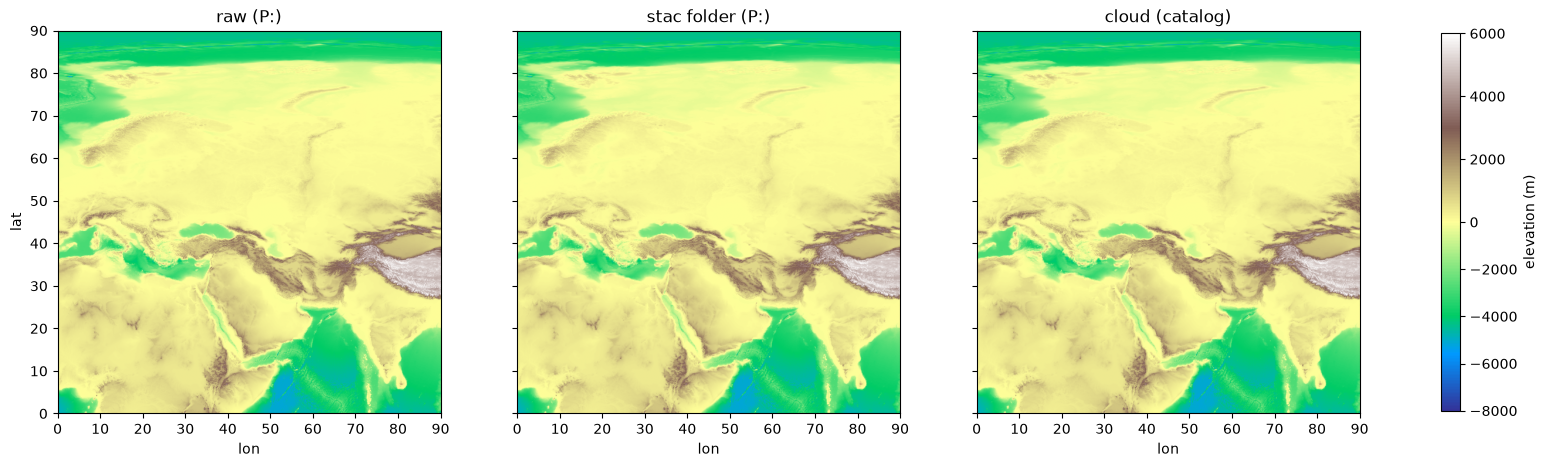

In [12]:
norm = TwoSlopeNorm(vmin=-8000, vcenter=0, vmax=6000)

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharex=True, sharey=True)
for ax, label in zip(axes, labels):
    for i in raw_paths:
        b = profiles[(i, label)]["bounds"]
        im = ax.imshow(
            np.ma.masked_equal(previews[(i, label)], -32767),
            cmap="terrain", norm=norm, extent=(b[0], b[2], b[1], b[3]),
        )
    ax.set_title(label)
    ax.set_xlabel("lon")
axes[0].set_ylabel("lat")
fig.colorbar(im, ax=axes, label="elevation (m)", shrink=0.7)
plt.show()

## 5) Compare

Same random windows (fixed seed) for the three sources. Compares shape, CRS/transform, the decimated previews and the window pixels.

In [13]:
ref = labels[0]
results = []
for i, srcs in paths.items():
    height, width = profiles[(i, ref)]["shape"]
    windows = [
        Window(int(rng.integers(0, width - WINDOW)), int(rng.integers(0, height - WINDOW)), WINDOW, WINDOW)
        for _ in range(N_WINDOWS)
    ]
    with rasterio.open(srcs[ref]) as src_ref:
        ref_windows = [src_ref.read(1, window=w) for w in windows]

    for other in labels[1:]:
        with rasterio.open(srcs[other]) as src_other:
            n_diff = sum(int((a != src_other.read(1, window=w)).sum()) for a, w in zip(ref_windows, windows))
        same_preview = np.array_equal(previews[(i, ref)], previews[(i, other)])
        same_grid = (profiles[(i, ref)]["crs"] or "", profiles[(i, ref)]["transform"], profiles[(i, ref)]["shape"]) == (
            profiles[(i, other)]["crs"] or "", profiles[(i, other)]["transform"], profiles[(i, other)]["shape"])
        results.append({
            "tile": i,
            "comparison": f"{ref} vs {other}",
            "same shape/transform": same_grid,
            "same preview": same_preview,
            f"different pixels in {N_WINDOWS} windows": n_diff,
            "identical": bool(same_grid and same_preview and n_diff == 0),
        })

    if FULL_COMPARE:
        with rasterio.open(srcs[ref]) as a, rasterio.open(srcs[labels[1]]) as b:
            n_full = 0
            for row in range(0, height, 2160):
                w = Window(0, row, width, min(2160, height - row))
                n_full += int((a.read(1, window=w) != b.read(1, window=w)).sum())
        print(f"{i}: full comparison raw vs stac folder, different pixels: {n_full}")

display(pd.DataFrame(results))

if all(r["identical"] for r in results):
    print("OK: raw, stac folder and cloud contain the same data (decimated preview and sampled windows).")
else:
    print("MISMATCH: see the table above.")

# Note: the raw tiles carry no CRS tag, the COGs are written as EPSG:4326, so 'same shape/transform' ignores a missing raw CRS
print("CRS raw:", {i: profiles[(i, ref)]["crs"] for i in raw_paths})

,tile,comparison,same shape/transform,same preview,different pixels in 6 windows,identical
0,gebco_2025_sub_ice_n0_s-90_w-90_e0,raw (P:) vs stac folder (P:),True,False,0,False
1,gebco_2025_sub_ice_n0_s-90_w-90_e0,raw (P:) vs cloud (catalog),True,False,0,False
2,gebco_2025_sub_ice_n0_s-90_w0_e90,raw (P:) vs stac folder (P:),True,False,0,False
3,gebco_2025_sub_ice_n0_s-90_w0_e90,raw (P:) vs cloud (catalog),True,False,0,False
4,gebco_2025_sub_ice_n90_s0_w-90_e0,raw (P:) vs stac folder (P:),True,False,0,False
5,gebco_2025_sub_ice_n90_s0_w-90_e0,raw (P:) vs cloud (catalog),True,False,0,False
6,gebco_2025_sub_ice_n90_s0_w0_e90,raw (P:) vs stac folder (P:),True,False,0,False
7,gebco_2025_sub_ice_n90_s0_w0_e90,raw (P:) vs cloud (catalog),True,False,0,False


MISMATCH: see the table above.
CRS raw: {'gebco_2025_sub_ice_n0_s-90_w-90_e0': 'EPSG:4326', 'gebco_2025_sub_ice_n0_s-90_w0_e90': 'EPSG:4326', 'gebco_2025_sub_ice_n90_s0_w-90_e0': 'EPSG:4326', 'gebco_2025_sub_ice_n90_s0_w0_e90': 'EPSG:4326'}


## 6) Call the WMS service

Requests the four layers published in GeoServer (step 8 of `scripts/21_gebco.ipynb`) through the `visual` asset of the STAC items, to check the service shows the same data. Needs access to the Deltares network. Colours come from the GeoServer style, so they will differ from the plots above.

WMS asset: https://international-delta-platform.avi.directory.intra/geoserver/wms/gebco
layers: gebco:gebco


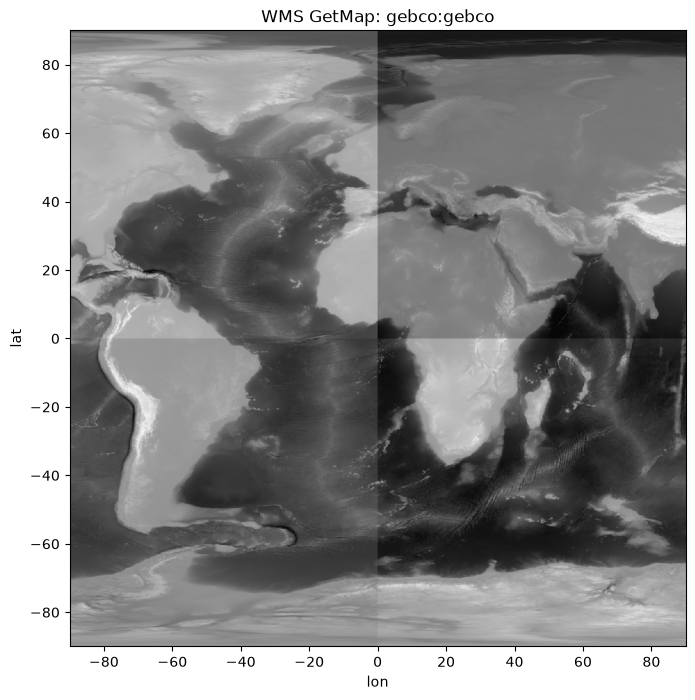

In [14]:
import io
import urllib3
import requests
import matplotlib.image as mpimg

urllib3.disable_warnings()  # the internal GeoServer uses a self-signed certificate

# WMS endpoint taken from the STAC items' "visual" asset (added by scripts/21_gebco.ipynb)
wms_url = next(iter(items.values())).assets["visual"].href
layers_tiles = ",".join(f"{collection_id}:{i}" for i in raw_paths)  # per-tile fallback layers
print("WMS asset:", wms_url)

def get_map(layers):
    params = dict(
        SERVICE="WMS", VERSION="1.1.1", REQUEST="GetMap", LAYERS=layers, STYLES="",
        SRS="EPSG:4326", BBOX="-90,-90,90,90", WIDTH=1080, HEIGHT=1080,
        FORMAT="image/png", TRANSPARENT="true",
    )
    r = requests.get(wms_url, params=params, verify=False, timeout=180)
    return r if r.headers.get("Content-Type", "").startswith("image") else None  # GeoServer returns XML on errors

# the mosaic layer (gebco:gebco) is published by step 8; otherwise the four per-tile layers
for layers in (f"{collection_id}:{collection_id}", layers_tiles):
    resp = get_map(layers)
    if resp is not None:
        print("layers:", layers)
        break
else:
    raise RuntimeError("GetMap failed for the mosaic and for the tile layers")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mpimg.imread(io.BytesIO(resp.content), format="png"), extent=(-90, 90, -90, 90))
ax.set_title(f"WMS GetMap: {layers}")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.show()